In [15]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [17]:
(x_train, y_train ), (x_test, y_test )= tf.keras.datasets.mnist.load_data()

In [18]:
x_train.shape

(60000, 28, 28)

In [19]:
x_test.shape

(10000, 28, 28)

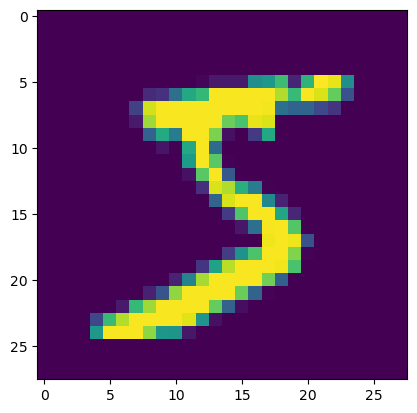

In [20]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0])

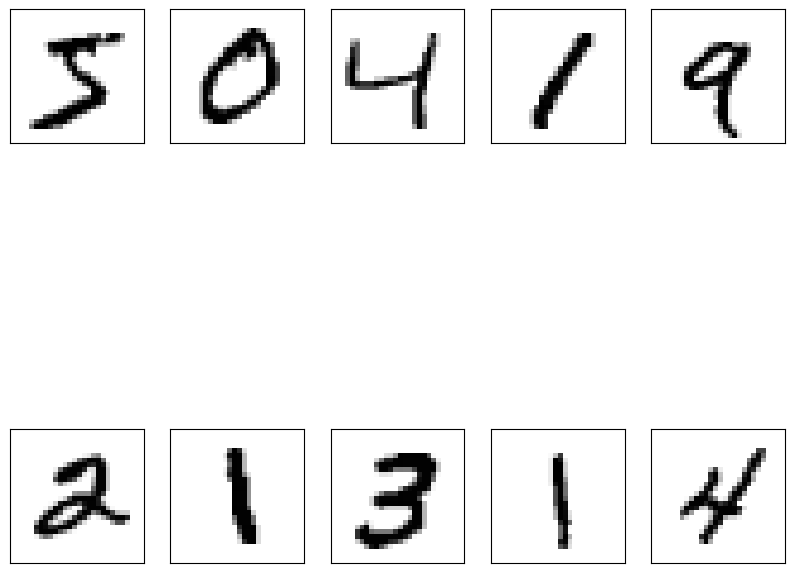

In [21]:
plt.figure(figsize=(10,10))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_train[i],cmap=plt.cm.binary)
plt.show()

In [22]:
# Data Preprocessing - Normalize images
x_train = x_train/255.0
x_test = x_test/255.0

In [23]:
model = Sequential([
    # Input Layer - 784 neurons in input Layer 
    Flatten(input_shape=(28,28)),
    #Hidden Layer(s)
    Dense(512, activation='sigmoid'),
    Dense(256, activation='sigmoid'),
    Dense(128, activation='sigmoid'),
    #Output Layer - 10 neurons
    Dense(10, activation='softmax')
    # Dense (1, activation="Sigmoid")
])

C:\Users\raian\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(optimizer = "adam",
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics = ["accuracy"])


In [26]:
model.fit(x_train, y_train, 
          validation_data=(x_test, y_test),
          epochs=5)

Epoch 1/5


C:\Users\raian\AppData\Roaming\Python\Python313\site-packages\keras\src\backend\tensorflow\nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - accuracy: 0.8887 - loss: 0.3745 - val_accuracy: 0.9441 - val_loss: 0.1804
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9579 - loss: 0.1384 - val_accuracy: 0.9651 - val_loss: 0.1104
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9714 - loss: 0.0929 - val_accuracy: 0.9718 - val_loss: 0.0894
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.9794 - loss: 0.0664 - val_accuracy: 0.9779 - val_loss: 0.0727
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9841 - loss: 0.0509 - val_accuracy: 0.9788 - val_loss: 0.0734


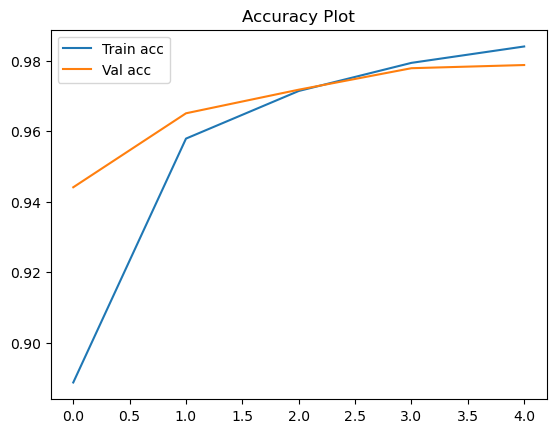

In [27]:
plt.plot(model.history.history["accuracy"], label="Train acc")
plt.plot(model.history.history["val_accuracy"], label="Val acc")
plt.legend()
plt.title("Accuracy Plot")
plt.show()

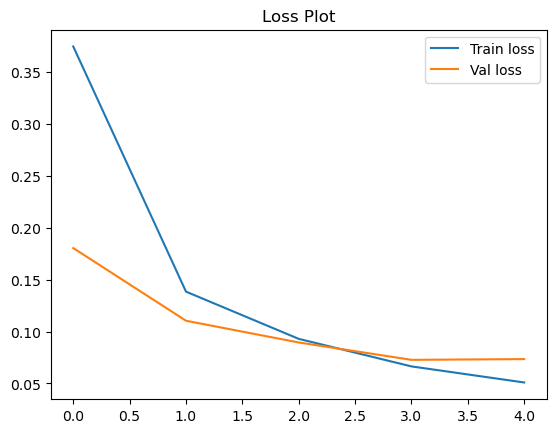

In [29]:
plt.plot(model.history.history["loss"], label="Train loss")
plt.plot(model.history.history["val_loss"], label="Val loss")
plt.legend()
plt.title("Loss Plot")
plt.show()